In [88]:
import pandas as pd

In [89]:
df = pd.read_csv('vacancies_with_roles.csv')
df.head()


,id,title,description,is_relevant,summary_duties,summary_requirements,summary_company,url,published_at,processed_at,...,published_date,work_format,working_hours,company,salary,experience,employment_type,schedule,semantic_role,similarity
0,6,Аналитик данных,"Привет! Мы — Tothemoon, одна из самых быстрора...",True,Настройка сквозной аналитики воронки привлечен...,4+ лет опыта аналитики в финтехе / крипте / e-...,Tothemoon - быстрорастущая криптовалютная бирж...,https://hh.kz/vacancy/120297653,2025-05-18,2025-05-19 07:03:57.418759,...,18 мая 2025,На месте работодателя,8,ООО РД Технологии,Не указано,3–6 лет,Полная занятость,5/2,BI Analyst,0.809033
1,17,Data Scientist на проект социальной сети (Juni...,"Мы LEGKO COMPANY – IT-студия, занимающаяся раз...",True,Анализ и обработка данных о поведении пользова...,Опыт работы от 2-х лет на позиции Data Scienti...,"LEGKO COMPANY – IT-студия, занимающаяся разраб...",https://hh.kz/vacancy/120661615,2025-05-18,2025-05-19 07:03:57.418759,...,18 мая 2025,Удалённо,"2, 3, 4 или по договорённости",ИП LEGKO company,Не указано,1–3 года,Частичная занятость\nВозможно временное оформл...,"по выходным, свободный и другие варианты",Data Scientist,0.835281
2,21,Бизнес/Системный аналитик (Full Stack Analityc),Обязанности:\n\nАнализировать требования к сис...,True,"Анализ требований к системам, их производитель...",Опыт работы в области бизнес/системного анализ...,Не указано,https://hh.kz/vacancy/120662304,2025-05-18,2025-05-19 07:03:57.418759,...,18 мая 2025,На месте работодателя или гибрид,8,ТОО Inter Solutions,"от 800 000 до 1 100 000 ₸ за месяц, на руки",3–6 лет,Полная занятость\nВозможно временное оформление,5/2,System Analyst,0.836392
3,24,Sales and Reporting Analyst в компанию INTERMO...,Key Responsibilities:\n\nDesign and optimize r...,True,Design and optimize reporting processes.\nPrep...,"Degree in Finance, Statistics, or related fiel...",Не указано,https://hh.kz/vacancy/120674218,2025-05-19,2025-05-19 07:03:57.418759,...,19 мая 2025,Не указано,8,ТОО Intermode (Интермоде),Не указано,3–6 лет,Полная занятость,5/2,BI Analyst,0.816597
4,59,Senior risk modeling analyst (скоринг модели),Компания KMF – лидер на рынке микрофинансирова...,True,Разработка скоринговых моделей\nПоддержка сист...,Высшее техническое/математическое/IT/финансы/э...,"KMF – лидер на рынке микрофинансирования, откр...",https://hh.kz/vacancy/120670021,2025-05-19,2025-05-19 07:03:57.418759,...,19 мая 2025,Не указано,8,АО Микрофинансовая организация KMF(КМФ),Не указано,3–6 лет,Полная занятость,5/2,Financial Analyst,0.800329


In [90]:
df['location'].value_counts().sort_values(ascending=False)

location
Алматы               770
Астана               351
Караганда             18
Шымкент               11
Костанай              11
Актобе                 6
Атырау                 6
Актау                  5
Кокшетау               4
Семей                  4
Усть-каменогорске      3
Кызылорде              2
Не указано             2
Тараз                  1
Павлодар               1
Уральск                1
Петропавловске         1
Талгаре                1
Name: count, dtype: int64

In [91]:
df.columns

Index(['id', 'title', 'description', 'is_relevant', 'summary_duties',
       'summary_requirements', 'summary_company', 'url', 'published_at',
       'processed_at', 'sent_to_telegram', 'location', 'salary_range',
       'skills', 'published_date', 'work_format', 'working_hours', 'company',
       'salary', 'experience', 'employment_type', 'schedule', 'semantic_role',
       'similarity'],
      dtype='object')

In [92]:
df['experience'].value_counts()

experience
3–6 лет         606
1–3 года        476
не требуется     68
более 6 лет      48
Name: count, dtype: int64

In [93]:
df['company'].value_counts()

company
Beeline, ТМ                                 47
АО Народный банк Казахстана. IT             45
ТОО Epam Kazakhstan (Эпам Казахстан),ТОО    43
Andersen                                    27
АО Home Credit Bank                         25
                                            ..
ТОО BenchMark Consulting                     1
ТОО Zymyran inc                              1
ТОО Click Intellect                          1
АО Jusan Invest                              1
Washly                                       1
Name: count, Length: 435, dtype: int64

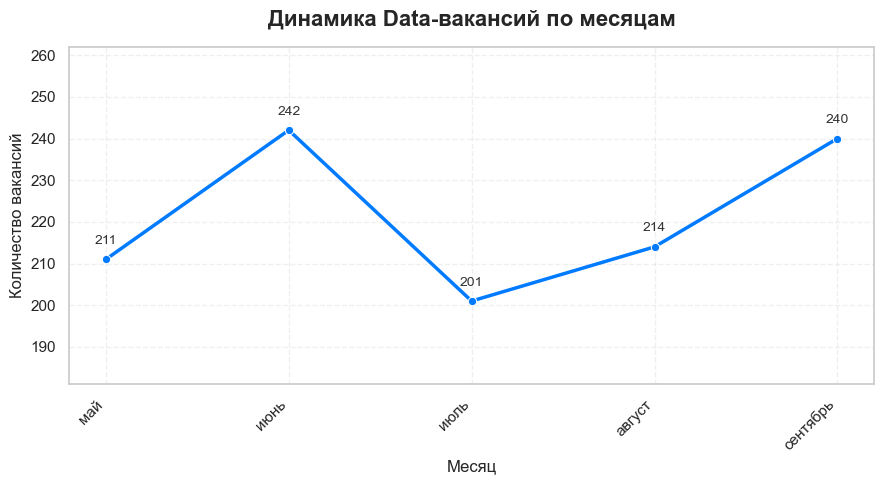

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Если published_at не datetime — конвертируем ===
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")
df = df.dropna(subset=["published_at"])

# === 2. Месяцы по-русски ===
month_map = {
    5: "май",
    6: "июнь",
    7: "июль",
    8: "август",
    9: "сентябрь",
    10: "октябрь",
}

df["month_num"] = df["published_at"].dt.month
df["month"] = df["month_num"].map(month_map)
df = df[df["month"] != "октябрь"]

# === 3. Агрегация ===
order = ["май", "июнь", "июль", "август", "сентябрь"]
monthly = (
    df.groupby("month")
    .size()
    .reindex(order, fill_value=0)
    .reset_index(name="count")
)

# === 4. Визуализация ===
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

sns.lineplot(
    x="month", y="count", data=monthly,
    marker="o", linewidth=2.5, color="#007BFF"
)

for x, y in zip(monthly["month"], monthly["count"]):
    plt.text(x, y + 3, f"{int(y)}", ha="center", va="bottom", fontsize=10, color="#333")

plt.title("Динамика Data-вакансий по месяцам", fontsize=16, weight="bold", pad=15)
plt.xlabel("Месяц", fontsize=12)
plt.ylabel("Количество вакансий", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.3)

# 👇 Добавляем ограничение оси Y
y_min = max(100, monthly["count"].min() - 20)
y_max = monthly["count"].max() + 20
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

In [95]:
df['published_at']

0      2025-05-18
1      2025-05-18
2      2025-05-18
3      2025-05-19
4      2025-05-19
          ...    
1103   2025-09-30
1104   2025-09-30
1105   2025-09-30
1106   2025-09-30
1107   2025-09-30
Name: published_at, Length: 1108, dtype: datetime64[ns]

In [96]:
df.columns

Index(['id', 'title', 'description', 'is_relevant', 'summary_duties',
       'summary_requirements', 'summary_company', 'url', 'published_at',
       'processed_at', 'sent_to_telegram', 'location', 'salary_range',
       'skills', 'published_date', 'work_format', 'working_hours', 'company',
       'salary', 'experience', 'employment_type', 'schedule', 'semantic_role',
       'similarity', 'month_num', 'month'],
      dtype='object')

In [97]:
df['work_format'].value_counts()

work_format
На месте работодателя                           471
Не указано                                      276
Удалённо                                        131
Гибрид                                           99
На месте работодателя или гибрид                 59
Удалённо или гибрид                              30
На месте работодателя, удалённо или гибрид       29
На месте работодателя или удалённо                7
На месте работодателя, гибрид или разъездной      6
Name: count, dtype: int64

In [98]:
df['salary'].value_counts()

salary
Не указано                                     938
от 500 000 ₸ за месяц, на руки                  18
от 600 000 ₸ за месяц, на руки                   9
от 400 000 ₸ за месяц, на руки                   7
от 300 000 до 500 000 ₸ за месяц, на руки        5
                                              ... 
от 800 000 до 1 500 000 ₸ за месяц, на руки      1
от 1 550 до 1 950 $ за месяц, на руки            1
от 300 000 до 350 000 ₸ за месяц, на руки        1
до 300 000 ₸ за месяц, на руки                   1
от 650 000 ₸ за месяц, на руки                   1
Name: count, Length: 85, dtype: int64

✅ Топ групп навыков:
       skill_group  count  percent
0        SQL stack    759     68.5
1     Python stack    519     46.8
2         BI tools    411     37.1
3        ETL / API    361     32.6
4   Infrastructure    345     31.1
5       OS / Shell    177     16.0
6          ML / DL    163     14.7
7  Version Control    145     13.1
8            Cloud    132     11.9


/var/folders/5d/7yv1cd4n6px6r2fxbtjflxsh0000gn/T/ipykernel_38868/180982579.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="percent", y="skill_group", data=skill_df, palette="Blues_r")


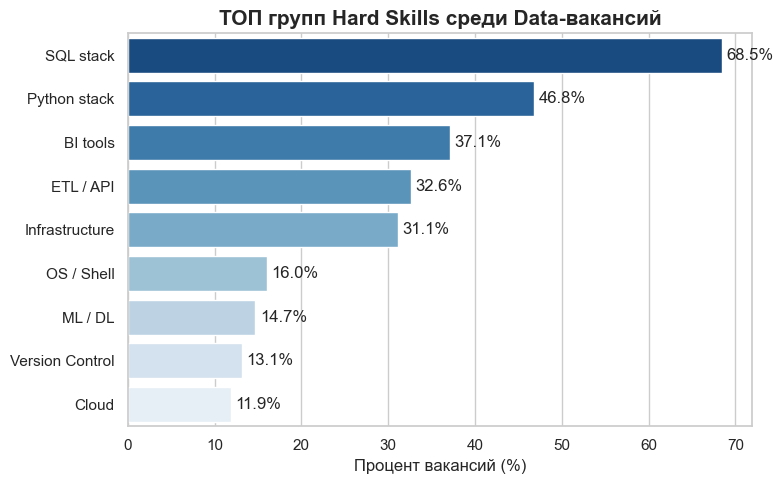

In [99]:
import pandas as pd
import re
from collections import Counter

text_col = "description"
df[text_col] = df[text_col].fillna("").astype(str)

HARD_SKILLS = [
    "python", "sql", "excel", "power bi", "tableau", "docker", "airflow",
    "spark", "hadoop", "kafka", "git", "linux", "bash", "shell", "aws",
    "azure", "gcp", "postgresql", "mysql", "mongodb", "oracle", "pandas",
    "numpy", "sklearn", "tensorflow", "pytorch", "keras", "jira", "clickhouse",
    "etl", "api", "ml", "machine learning", "deep learning", "statistics",
]

# === Маппинг для объединения похожих ===
SKILL_GROUPS = {
    "SQL stack": ["sql", "postgresql", "mysql", "oracle", "clickhouse"],
    "Python stack": ["python", "pandas", "numpy", "sklearn", "tensorflow", "pytorch", "keras"],
    "BI tools": ["power bi", "tableau", "excel"],
    "Infrastructure": ["docker", "airflow", "kafka", "spark", "hadoop"],
    "Cloud": ["aws", "azure", "gcp"],
    "Version Control": ["git"],
    "OS / Shell": ["linux", "bash", "shell"],
    "ETL / API": ["etl", "api"],
    "ML / DL": ["ml", "machine learning", "deep learning", "statistics"],
}

def extract_skills(text):
    text = text.lower()
    found = []
    for skill in HARD_SKILLS:
        if re.search(rf"\b{re.escape(skill)}\b", text):
            found.append(skill)
    return found

df["found_skills"] = df[text_col].apply(extract_skills)

# === Считаем частоту по группам ===
group_counts = Counter()
for skills in df["found_skills"]:
    for group, keywords in SKILL_GROUPS.items():
        if any(s in skills for s in keywords):
            group_counts[group] += 1

skill_df = pd.DataFrame(group_counts.items(), columns=["skill_group", "count"])
skill_df["percent"] = (skill_df["count"] / len(df) * 100).round(1)
skill_df = skill_df.sort_values("count", ascending=False).reset_index(drop=True)

print("✅ Топ групп навыков:")
print(skill_df)

# === Визуализация ===
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x="percent", y="skill_group", data=skill_df, palette="Blues_r")
plt.title("ТОП групп Hard Skills среди Data-вакансий", fontsize=15, weight="bold")
plt.xlabel("Процент вакансий (%)")
plt.ylabel("")

for i, (p, v) in enumerate(zip(skill_df["percent"], skill_df["skill_group"])):
    plt.text(p + 0.5, i, f"{p}%", va="center")

plt.tight_layout()
plt.show()

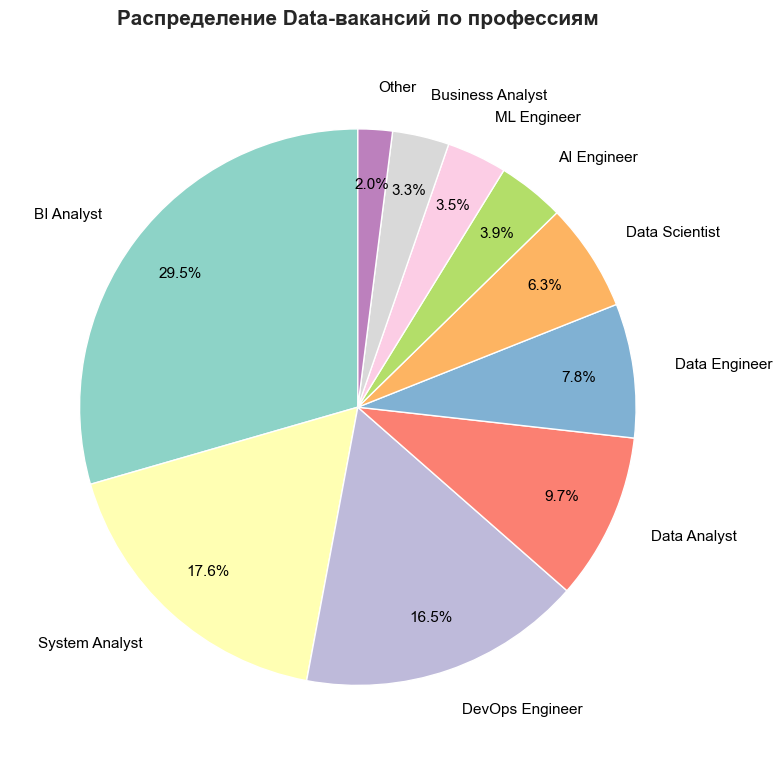

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Данные ===
roles = {
    "BI Analyst": 29.5,
    "System Analyst": 17.6,
    "DevOps Engineer": 16.5,
    "Data Analyst": 9.7,
    "Data Engineer": 7.8,
    "Data Scientist": 6.3,
    "AI Engineer": 3.9,
    "ML Engineer": 3.5,
    "Business Analyst": 3.3,
    "Financial Analyst": 1.7,
    "MLOps Engineer": 0.3,
}

df = pd.DataFrame(list(roles.items()), columns=["role", "percent"])

# === 2. Группируем мелкие роли (<3%) в "Other" ===
threshold = 3.0
df["role_grouped"] = df["role"]
df.loc[df["percent"] < threshold, "role_grouped"] = "Other"

df_grouped = df.groupby("role_grouped", as_index=False)["percent"].sum()
df_grouped = df_grouped.sort_values("percent", ascending=False)

# === 3. Визуализация ===
plt.figure(figsize=(8, 8))
colors = plt.cm.Set3.colors  # приятная мягкая палитра

wedges, texts, autotexts = plt.pie(
    df_grouped["percent"],
    labels=df_grouped["role_grouped"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    labeldistance=1.15,
    textprops={"fontsize": 11, "color": "black"},
    wedgeprops={"edgecolor": "white"},
)

# === 4. Заголовок и оформление ===
plt.title("Распределение Data-вакансий по профессиям", fontsize=15, weight="bold", pad=25)
plt.tight_layout()

# === 5. Сохраняем ===
plt.show()

/var/folders/5d/7yv1cd4n6px6r2fxbtjflxsh0000gn/T/ipykernel_38868/3780110520.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


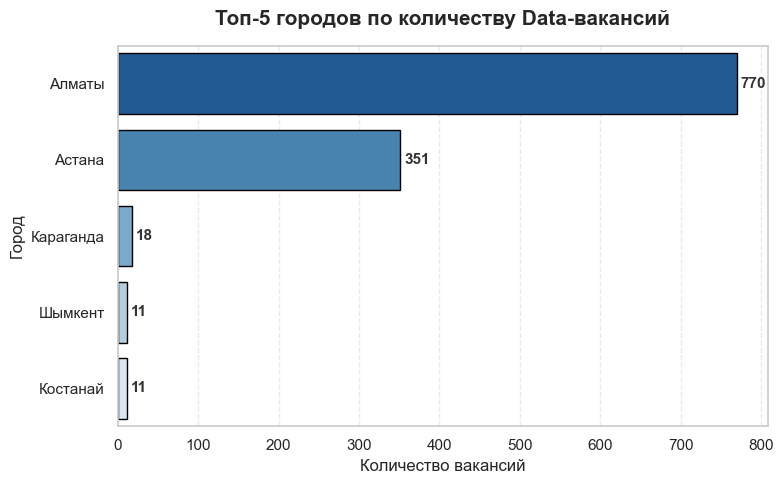

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('vacancies_with_roles.csv')
# === 1. Готовим данные ===
top_cities = (
    df["location"]
    .dropna()
    .value_counts()
    .head(5)
    .reset_index()
)
top_cities.columns = ["city", "count"]

# === 2. Настройка стиля ===
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# === 3. Горизонтальные бары ===
ax = sns.barplot(
    data=top_cities,
    y="city",
    x="count",
    palette="Blues_r",
    edgecolor="black"
)

# === 4. Подписи на барах ===
for i, (count, city) in enumerate(zip(top_cities["count"], top_cities["city"])):
    ax.text(count + 5, i, f"{count}", va="center", fontsize=11, color="#333", weight="bold")

# === 5. Украшение ===
plt.title("Топ-5 городов по количеству Data-вакансий", fontsize=15, weight="bold", pad=15)
plt.xlabel("Количество вакансий", fontsize=12)
plt.ylabel("Город", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

# === 6. Сохранение ===
plt.show()

In [ ]:
df.columns

Index(['role', 'percent'], dtype='object')